<a href="https://colab.research.google.com/github/talhasyed993-spec/AI-Internship-Tasks-2/blob/main/News_Classifier_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# News Topic Classification Using BERT

## Problem Statement

News websites publish thousands of articles every day. Manually categorizing these articles into topics such as World, Sports, Business, and Science/Technology is time-consuming and inefficient.

The objective of this project is to develop a deep learning model using Google's BERT (Bidirectional Encoder Representations from Transformers) to automatically classify news headlines into their correct categories.

## Objectives

- Load the AG News dataset from CSV files.
- Preprocess the text.
- Tokenize using BERT tokenizer.
- Fine-tune the pretrained bert-base-uncased model.
- Evaluate using Accuracy and F1-score.
- Visualize model performance.
- Deploy using Gradio.

In [1]:
!pip -q install -U transformers datasets evaluate accelerate gradio scikit-learn seaborn

# verifying the installed version

In [2]:
import transformers
import datasets
import huggingface_hub
import accelerate
import gradio

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
print("gradio:", gradio.__version__)

transformers: 5.13.1
datasets: 5.0.0
huggingface_hub: 1.23.0
accelerate: 1.14.0
gradio: 6.20.0


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

import warnings
warnings.filterwarnings("ignore")

In [5]:
from google.colab import files

# Prompting you to choose the files from your computer
print("Please select your 'train.csv' and 'test.csv' files together:")
uploaded = files.upload()


Please select your 'train.csv' and 'test.csv' files together:


Saving test.csv to test.csv
Saving train.csv to train.csv


In [6]:
import io
import pandas as pd

# Reading the uploaded train file
if 'train.csv' in uploaded:
    train_df = pd.read_csv(io.BytesIO(uploaded['train.csv']))
    print("Train dataset loaded successfully! Shape:", train_df.shape)
else:
    print("Error: 'train.csv' was not found in the uploaded files. Check the exact file name.")

# Reading the uploaded test file
if 'test.csv' in uploaded:
    test_df = pd.read_csv(io.BytesIO(uploaded['test.csv']))
    print("Test dataset loaded successfully! Shape:", test_df.shape)
else:
    print("Error: 'test.csv' was not found in the uploaded files. Check the exact file name.")


Train dataset loaded successfully! Shape: (119999, 3)
Test dataset loaded successfully! Shape: (7600, 3)


In [8]:
import pandas as pd

column_names = ["label", "title", "description"]

train_df = pd.read_csv(
    "train.csv",
    header=None,
    names=column_names
)

test_df = pd.read_csv(
    "test.csv",
    header=None,
    names=column_names
)

print(train_df.head())
print(train_df.shape)

   label                                              title  \
0      3  Wall St. Bears Claw Back Into the Black (Reuters)   
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      3  Iraq Halts Oil Exports from Main Southern Pipe...   
4      3  Oil prices soar to all-time record, posing new...   

                                         description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  
(120000, 3)


In [9]:
print(train_df.shape)
print(test_df.shape)

(120000, 3)
(7601, 3)


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [11]:
train_df.isnull().sum()

,0
label,0
title,0
description,0


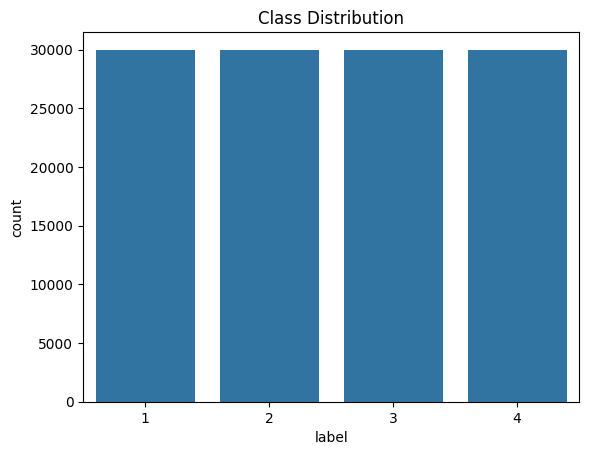

In [12]:
sns.countplot(
    x=train_df.iloc[:,0]
)

plt.title("Class Distribution")

plt.show()

# tokenization

In [13]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [14]:
def tokenize(batch):

    return tokenizer(

        batch["text"],

        truncation=True,

        padding="max_length",

        max_length=128

    )

# Convert to Hugging Face Dataset

In [18]:
train_dataset = Dataset.from_pandas(train_df)

test_dataset = Dataset.from_pandas(test_df)

In [19]:
print(train_df.columns)
print(train_df.head())

Index(['label', 'title', 'description'], dtype='object')
   label                                              title  \
0      3  Wall St. Bears Claw Back Into the Black (Reuters)   
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      3  Iraq Halts Oil Exports from Main Southern Pipe...   
4      3  Oil prices soar to all-time record, posing new...   

                                         description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


In [20]:
# Combine title and description
train_df["text"] = (
    train_df["title"].fillna("") + " " +
    train_df["description"].fillna("")
)

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["description"].fillna("")
)

In [22]:
train_df = train_df[["text", "label"]]
test_df = test_df[["text", "label"]]

In [23]:
print(train_df.columns)
print(train_df.head())

Index(['text', 'label'], dtype='object')
                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


In [24]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

print(train_dataset)
print(train_dataset.column_names)

Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})
['text', 'label']


In [25]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [26]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7601 [00:00<?, ? examples/s]

# Set the dataset formate

In [17]:
model = BertForSequenceClassification.from_pretrained(

    "bert-base-uncased",

    num_labels=4
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Convert to Hugging Face Dataset

In [28]:
train_dataset = Dataset.from_pandas(train_df)

test_dataset = Dataset.from_pandas(test_df)

In [29]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7601 [00:00<?, ? examples/s]

# Load Dataset

In [30]:
model = BertForSequenceClassification.from_pretrained(

    "bert-base-uncased",

    num_labels=4
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Metrics

In [31]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        preds,

        average="weighted"

    )

    accuracy = accuracy_score(labels, preds)

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1
    }

# Training Arguments

In [33]:
import transformers
print(transformers.__version__)

5.13.1


In [34]:
from transformers import TrainingArguments
import inspect

print(inspect.signature(TrainingArguments.__init__))

(self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_co

In [36]:
evaluation_strategy="epoch",

In [37]:
eval_strategy="epoch",

In [40]:
import transformers
print(transformers.__version__)

from transformers import TrainingArguments
import inspect
print(inspect.signature(TrainingArguments.__init__))

5.13.1
(self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, t

In [41]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    # Evaluation & Saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    # Training
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    # Logging
    logging_strategy="steps",
    logging_steps=100,
    report_to="none",

    # Reproducibility
    seed=42
)

# trainer

In [42]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [46]:
trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

# Evaluation

In [2]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

print(classification_report(
    predictions.label_ids,
    preds
))

NameError: name 'trainer' is not defined

# Confusion Metrix

In [3]:
cm = confusion_matrix(
    predictions.label_ids,
    preds
)

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

NameError: name 'confusion_matrix' is not defined

# Save Model

In [4]:
trainer.save_model("News_BERT_Model")

tokenizer.save_pretrained("News_BERT_Model")

NameError: name 'trainer' is not defined